In [66]:
# Imports
import os, json
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)

In [67]:
# Parameters
# Set raw_dir to the path of a run's raw/ folder. Use a raw string on Windows, e.g., r'C\\path\\to\\run\\raw'
# If left as None, the next cell will try to auto-detect a suitable raw/ folder.
raw_dir = None  # e.g., r'C:\\Users\\1213123\\Documents\\Scripts\\FoundationStereo\\scripts\\unity_yolo\\output_3d_blocks\\your_run\\raw'

buffer_px = 1
roi_margin_px = 8
method = 'canny'  # 'sobel' | 'laplacian' | 'canny'
edge_thresh = None  # absolute threshold for sobel/laplacian (meters/pixel); if None uses percentile
edge_sigma = 0.33  # for automatic thresholding if edge_thresh is None
flatten_far_m = 5.0  # if depth > T meters, set to T to reduce sky/background artifacts
max_edge_dist_px = 5.0  # maximum allowed distance from loaded edge to keep a depth edge
# Smoothing (pre-filter) to reduce noise before edge detection
# If True, a Gaussian blur will be applied (applies to depth for sobel/laplacian,
# and to the normalized image for Canny). Ensure ksize is odd and >=1.
smooth = True
smooth_ksize = 5  # must be odd (1,3,5,...); use 1 to disable smoothing effectually
smooth_sigma = 1.0  # sigma for Gaussian; 0 means let OpenCV compute from ksize

# Roots to search for runs if raw_dir is None or invalid (relative to this notebook location)
search_roots = [
    r'./output_3d_blocks',
    r'../output_3d_blocks',
    r'../../scripts/unity_yolo/output_3d_blocks',
    r'./scripts/unity_yolo/output_3d_blocks',
    r'../run_files/micro/output_3d_blocks',
    r'../run_files/micro/input_3d_blocks',
]

print('Initial raw_dir:', raw_dir)
print('buffer_px =', buffer_px)
print('roi_margin_px =', roi_margin_px)
print('method =', method)
print('edge_thresh =', edge_thresh, 'edge_sigma =', edge_sigma)
print('flatten_far_m =', flatten_far_m)
print('max_edge_dist_px =', max_edge_dist_px)
print('smooth =', smooth, 'smooth_ksize =', smooth_ksize, 'smooth_sigma =', smooth_sigma)

Initial raw_dir: None
buffer_px = 1
roi_margin_px = 8
method = canny
edge_thresh = None edge_sigma = 0.33
flatten_far_m = 5.0
max_edge_dist_px = 5.0
smooth = True smooth_ksize = 5 smooth_sigma = 1.0


In [68]:
# Step 0.5: Load camera intrinsics early (no depth scaling)
# This discovers Unity intrinsics (fx, fy, cx, cy) from a step0.frame_data.json if available.
# Intrinsics are used later to pixel-normalize depth gradients for edge detection.

# Optional: provide JSON path directly; otherwise we'll auto-discover similar to Step 8.6
early_step0_json_path = None  # e.g., r'C\\path\\to\\step0.frame_data.json'

import os, json

def _find_step0_json_early(start_dirs):
    names = ['step0.frame_data.json', 'frame_data.json']
    for root in start_dirs:
        try:
            root_abs = os.path.abspath(root)
            if not os.path.isdir(root_abs):
                continue
            for dirpath, dirnames, filenames in os.walk(root_abs):
                for n in filenames:
                    if n.lower() in names:
                        return os.path.join(dirpath, n)
        except Exception:
            pass
    return None

# Build candidate roots based on current notebook context
_early_candidates = []
if raw_dir is not None:
    _early_candidates += [raw_dir, os.path.dirname(raw_dir), os.path.dirname(os.path.dirname(raw_dir))]
_early_candidates += search_roots

if early_step0_json_path is None:
    early_step0_json_path = _find_step0_json_early(_early_candidates)


    with open(early_step0_json_path, 'r') as f:
        _camdata = json.load(f)
    captures = _camdata.get('captures', [])
    cam = None
    for c in captures:
        if c.get('@type', '').endswith('RGBCamera'):
            cam = c
            break
    if cam is None:
        print('Early intrinsics: No RGBCamera capture found in JSON.')
    else:
        dim = cam.get('dimension', None)
        proj = cam.get('matrix', None)
        if (not dim) or (not proj) or len(dim) < 2 or len(proj) < 9:
            print('Early intrinsics: JSON missing expected fields: dimension or matrix.')
        else:
            width = float(dim[0]); height = float(dim[1])
            P00 = float(proj[0]); P11 = float(proj[4])
            fx = P00 * width / 2.0
            fy = P11 * height / 2.0
            cx = width / 2.0
            cy = height / 2.0
            globals()['fx'] = fx; globals()['fy'] = fy; globals()['cx'] = cx; globals()['cy'] = cy
            print(f'Early intrinsics: fx={fx:.3f}, fy={fy:.3f}, cx={cx:.3f}, cy={cy:.3f}')
            print('These intrinsics will be used to pixel-normalize Sobel depth gradients for edge detection.')
    del _camdata


Early intrinsics: fx=253.906, fy=253.906, cx=325.000, cy=200.000
These intrinsics will be used to pixel-normalize Sobel depth gradients for edge detection.


In [69]:
# Auto-detect and validate raw_dir
import time

def has_required_files(run_dir: str) -> bool:
    d_npy = os.path.join(run_dir, 'depth.npy')
    d_exr = os.path.join(run_dir, 'depth.exr')
    e_npy = os.path.join(run_dir, 'edges.npy')
    e_png = os.path.join(run_dir, 'edges.png')
    return (os.path.isfile(d_npy) or os.path.isfile(d_exr)) and (os.path.isfile(e_npy) or os.path.isfile(e_png))

if raw_dir is None or not os.path.isdir(raw_dir) or not has_required_files(raw_dir):
    print('Trying to auto-detect a raw/ folder...')
    candidates = []
    for root in search_roots:
        root_abs = os.path.abspath(root)
        if not os.path.isdir(root_abs):
            continue
        for dirpath, dirnames, filenames in os.walk(root_abs):
            if os.path.basename(dirpath).lower() == 'raw' and has_required_files(dirpath):
                # Score by most recent mtime among contained files
                try:
                    mtimes = [os.path.getmtime(os.path.join(dirpath, f)) for f in filenames]
                    score = max(mtimes) if mtimes else 0
                except Exception:
                    score = 0
                candidates.append((score, dirpath))
    if candidates:
        candidates.sort(reverse=True)
        print('Found candidates:')
        for i, (score, path) in enumerate(candidates[:10], 1):
            ts = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(score))
            print(f'  {i}. {path}  (latest file: {ts})')
        raw_dir = candidates[0][1]
        print('Selected raw_dir =', raw_dir)
    else:
        raise FileNotFoundError('Could not auto-detect a valid raw/ folder. Please set raw_dir to a specific path.')
else:
    print('Using provided raw_dir =', raw_dir)

# Quick peek at files inside raw_dir
try:
    names = os.listdir(raw_dir)
    print('raw_dir contents (first 20):')
    for n in names[:20]:
        print(' -', n)
except Exception as e:
    print('Warning: could not list raw_dir:', e)

Trying to auto-detect a raw/ folder...
Found candidates:
  1. c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\micro\output_3d_blocks\raw  (latest file: 2025-11-07 20:02:15)
Selected raw_dir = c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\micro\output_3d_blocks\raw
raw_dir contents (first 20):
 - depth.exr
 - depth.npy
 - depth_boundary.npz
 - depth_boundary.ply
 - depth_boundary_points.npz
 - depth_mm.png
 - disparity.exr
 - disparity.npy
 - disparity_u16.png
 - edges.npy
 - edges.png
 - last_export_pointcloud.json
 - meta.json


In [70]:
# Helpers (ported from analyze_depth_edges.py)
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def load_raw(raw_dir: str):
    depth_npy = os.path.join(raw_dir, 'depth.npy')
    edges_npy = os.path.join(raw_dir, 'edges.npy')
    depth_exr = os.path.join(raw_dir, 'depth.exr')
    edges_png = os.path.join(raw_dir, 'edges.png')

    if os.path.exists(depth_npy):
        depth = np.load(depth_npy).astype(np.float32)
    elif os.path.exists(depth_exr):
        d = imageio.imread(depth_exr)
        # If 3-channel EXR with value in red channel
        if d.ndim == 3 and d.shape[2] >= 1:
            depth = d[...,0].astype(np.float32)
        else:
            depth = d.astype(np.float32)
    else:
        raise FileNotFoundError('Could not find depth.npy or depth.exr in raw_dir')

    # Treat zero depth as very far: set zeros to a large value for downstream logic
    # This preserves dtype (float32) and keeps NaNs/inf unchanged.
    zero_mask = (depth == 0)
    if zero_mask.any():
        depth[zero_mask] = 1.0

    if os.path.exists(edges_npy):
        edges = np.load(edges_npy)
        if edges.dtype != np.uint8:
            edges = edges.astype(np.uint8)
        edges_bin = (edges > 0).astype(np.uint8)
    elif os.path.exists(edges_png):
        e = cv2.imread(edges_png, cv2.IMREAD_GRAYSCALE)
        edges_bin = (e > 0).astype(np.uint8)
    else:
        raise FileNotFoundError('Could not find edges.npy or edges.png in raw_dir')
    return depth, edges_bin

def depth_meter_to_pixel(depth_m: np.ndarray, fx: float, fy: float) -> np.ndarray:
    h, w = depth_m.shape[:2]
    y_idxs, x_idxs = np.indices((h, w), dtype=np.float32)
    x_norm = (x_idxs - (w / 2.0)) / fx
    y_norm = (y_idxs - (h / 2.0)) / fy
    depth_px = np.sqrt((depth_m * x_norm) ** 2 + (depth_m * y_norm) ** 2 + depth_m ** 2)
    return depth_px

def buffer_edges(edges_bin: np.ndarray, buffer_px: int) -> np.ndarray:
    if buffer_px <= 0:
        return edges_bin.copy()
    k = 2 * buffer_px + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    return cv2.dilate(edges_bin, kernel, iterations=1)

def compute_roi_from_mask(mask: np.ndarray, margin: int = 0):
    ys, xs = np.where(mask > 0)
    if ys.size == 0 or xs.size == 0:
        return None
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    if margin > 0:
        y1 -= margin; y2 += margin; x1 -= margin; x2 += margin
    h, w = mask.shape[:2]
    y1 = max(0, y1); x1 = max(0, x1)
    y2 = min(h - 1, y2); x2 = min(w - 1, x2)
    return x1, y1, x2, y2

def visualize_depth(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.zeros((*d.shape, 3), dtype=np.uint8)
    dmin = float(np.percentile(d[valid], 5))
    dmax = float(np.percentile(d[valid], 95))
    if dmax <= dmin:
        dmax = dmin + 1e-6
    d_clipped = np.clip(d, dmin, dmax)
    d_norm = (d_clipped - dmin) / (dmax - dmin)
    d_norm[~valid] = 0
    img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
    color = cv2.applyColorMap(img_u8, cv2.COLORMAP_TURBO)
    color[~valid] = 0
    return color

def fill_invalid_with_median(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
    med = float(np.median(d[valid]))
    d[~valid] = med
    return d

def detect_depth_edges(depth_roi: np.ndarray, method: str, edge_thresh: float | None, edge_sigma: float | None, smooth: bool = True, smooth_ksize: int = 5, smooth_sigma: float = 1.0):
    """
    Detect depth edges inside a ROI. Optionally apply Gaussian smoothing first to reduce noise.

    Args:
        depth_roi: 2D depth array (float32)
        method: 'sobel' | 'laplacian' | 'canny'
        edge_thresh: absolute threshold for gradient-based methods (meters/pixel)
        edge_sigma: sigma for automatic thresholding if edge_thresh is None
        smooth: whether to apply Gaussian smoothing before edge ops
        smooth_ksize: kernel size (must be odd >=1)
        smooth_sigma: gaussian sigma (0 -> computed from ksize)

    Returns:
        grad: gradient magnitude or Canny result (float32)
        edges_bin: binary edge mask (0/255 uint8)
    """

    d_filled = fill_invalid_with_median(depth_roi.astype(np.float32))

    # sanitize ksize
    if smooth_ksize is None:
        smooth_ksize = 1
    if smooth_ksize <= 0:
        smooth_ksize = 1
    if smooth_ksize % 2 == 0:
        smooth_ksize += 1

    if method == 'sobel':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        dx = cv2.Sobel(d_proc, cv2.CV_32F, 1, 0, ksize=3)
        dy = cv2.Sobel(d_proc, cv2.CV_32F, 0, 1, ksize=3)
        grad = np.sqrt(dx * dx + dy * dy)
    elif method == 'laplacian':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        grad = cv2.Laplacian(d_proc, cv2.CV_32F, ksize=3)
        grad = np.abs(grad)
    elif method == 'canny':
        img_u8 = np.uint8(depth_roi)

        if edge_thresh is None and edge_sigma is not None:
            # compute the median of the single channel pixel intensities
            v = np.mean(img_u8)
            low = int(max(0, (1.0 - edge_sigma) * v))
            high = int(min(255, (1.0 + edge_sigma) * v))
        else:
            low, high = 10, 25
        edges = cv2.Canny(img_u8, low, high)
        grad = edges.astype(np.float32)
    else:
        raise ValueError('Unknown method. Choose from: sobel, laplacian, canny')

    if method in ('sobel', 'laplacian'):
        if edge_thresh is not None:
            th = float(edge_thresh)
        elif edge_sigma is not None:
            th = float(np.percentile(grad, edge_sigma))
        else:
            th = float(np.percentile(grad, 95))
        edges_bin = (grad >= th).astype(np.uint8) * 255
    else:
        edges_bin = (grad > 0).astype(np.uint8) * 255
    return grad, edges_bin


In [71]:
# Override: Detect depth edges with Sobel gradient for Canny
# This redefines detect_depth_edges so that when method == 'canny',
# it computes and returns the Sobel gradient magnitude in pixel units (if intrinsics available)
# and Canny edges (uint8) computed on a normalized, optionally smoothed image.


def detect_depth_edges(
    depth_roi: np.ndarray,
    method: str,
    edge_thresh: float | None,
    edge_sigma: float | None,
    smooth: bool = True,
    smooth_ksize: int = 5,
    smooth_sigma: float = 1.0,
):
    """
    Detect depth edges inside a ROI. Optionally apply Gaussian smoothing first to reduce noise.

    Args:
        depth_roi: 2D depth array (float32) containing metric depth (meters)
        method: 'sobel' | 'laplacian' | 'canny'
        edge_thresh: threshold for gradient-based methods (interpreted on the returned grad domain)
        edge_sigma: percentile for auto threshold (sobel/laplacian) or ratio for auto Canny thresholds when edge_thresh is None
        smooth: whether to apply Gaussian smoothing before edge ops
        smooth_ksize: kernel size (must be odd >=1)
        smooth_sigma: gaussian sigma (0 -> computed from ksize)

    Returns:
        grad: gradient magnitude (float32). For method='canny', this is Sobel gradient magnitude.
              If intrinsics (fx, fy) are available, grad is pixel-normalized: sqrt((fx/Z * dD/du)^2 + (fy/Z * dD/dv)^2).
              Otherwise, grad is in meters/pixel.
        edges_bin: binary edge mask (0/255 uint8). For method='canny', from cv2.Canny on normalized, smoothed 8-bit image.
    """

    d = depth_roi.astype(np.float32)
    d_filled = fill_invalid_with_median(d)

    # sanitize ksize
    if smooth_ksize is None:
        smooth_ksize = 1
    if smooth_ksize <= 0:
        smooth_ksize = 1
    if smooth_ksize % 2 == 0:
        smooth_ksize += 1

    def _pixel_normalize_grad(dx_m_per_px: np.ndarray, dy_m_per_px: np.ndarray, z_m: np.ndarray) -> np.ndarray:
        """Convert metric depth gradients (m/px) to pixel-normalized magnitude using fx, fy, Z.
        grad_px = sqrt( (fx/Z * dx)^2 + (fy/Z * dy)^2 ). Falls back to metric magnitude if intrinsics missing.
        """
        has_intr = ('fx' in globals()) and ('fy' in globals()) and np.isfinite(globals()['fx']) and np.isfinite(globals()['fy'])
        if not has_intr:
            return np.sqrt(dx_m_per_px * dx_m_per_px + dy_m_per_px * dy_m_per_px)
        fx_val = float(globals()['fx']); fy_val = float(globals()['fy'])
        Z = np.maximum(z_m.astype(np.float32), 1e-6)
        gx = (fx_val / Z) * dx_m_per_px
        gy = (fy_val / Z) * dy_m_per_px
        return np.sqrt(gx * gx + gy * gy)

    if method == 'sobel':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        dx = cv2.Sobel(d_proc, cv2.CV_32F, 1, 0, ksize=3)  # m/px
        dy = cv2.Sobel(d_proc, cv2.CV_32F, 0, 1, ksize=3)  # m/px
        grad = _pixel_normalize_grad(dx, dy, d_proc)
        if edge_thresh is not None:
            th = float(edge_thresh)
        elif edge_sigma is not None:
            th = float(np.percentile(grad, edge_sigma))
        else:
            th = float(np.percentile(grad, 95))
        edges_bin = (grad >= th).astype(np.uint8) * 255
        return grad, edges_bin

    if method == 'laplacian':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        # Laplacian has different units (m/px^2). We keep absolute value; pixel-normalization is non-trivial here.
        grad = cv2.Laplacian(d_proc, cv2.CV_32F, ksize=3)
        grad = np.abs(grad)
        if edge_thresh is not None:
            th = float(edge_thresh)
        elif edge_sigma is not None:
            th = float(np.percentile(grad, edge_sigma))
        else:
            th = float(np.percentile(grad, 95))
        edges_bin = (grad >= th).astype(np.uint8) * 255
        return grad, edges_bin

    if method == 'canny':
        # Prepare smoothed depth for gradient magnitude
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_proc, (smooth_ksize, smooth_ksize), smooth_sigma)

        # Compute Sobel gradient magnitude and convert to pixel units if intrinsics available
        dx = cv2.Sobel(d_proc, cv2.CV_32F, 1, 0, ksize=1)  # m/px
        dy = cv2.Sobel(d_proc, cv2.CV_32F, 0, 1, ksize=1)  # m/px
        grad = _pixel_normalize_grad(dx, dy, d_proc)

        # Build an 8-bit image for Canny using robust percentile normalization of the ORIGINAL (unfilled) depth
        valid = np.isfinite(d) & (d > 0)
        if valid.any():
            dmin = float(np.percentile(d[valid], 5))
            dmax = float(np.percentile(d[valid], 95))
            if dmax <= dmin:
                dmax = dmin + 1e-6
            d_norm = (np.clip(d, dmin, dmax) - dmin) / (dmax - dmin)
        else:
            d_norm = np.zeros_like(d, dtype=np.float32)
        img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)

        # Optional smoothing before Canny (image-space)
        if smooth and smooth_ksize > 1:
            img_u8 = cv2.GaussianBlur(img_u8, (smooth_ksize, smooth_ksize), smooth_sigma)

        # Auto thresholds based on mean intensity
        if edge_thresh is None and edge_sigma is not None:
            nz = img_u8 > 0
            v = float(img_u8[nz].mean()) if nz.any() else float(img_u8.mean())
            low = int(max(0, (1.0 - edge_sigma) * v))
            high = int(min(255, (1.0 + edge_sigma) * v))
        else:
            low, high = 50, 150

        edges = cv2.Canny(img_u8, low, high)
        edges_bin = (edges > 0).astype(np.uint8) * 255
        return grad, edges_bin

    raise ValueError("Unknown method. Choose from: sobel, laplacian, canny")

Depth shape: (400, 650) dtype: float32 min: 0.96479243 max: 99.90165
Edges shape: (400, 650) dtype: uint8 nonzero: 535


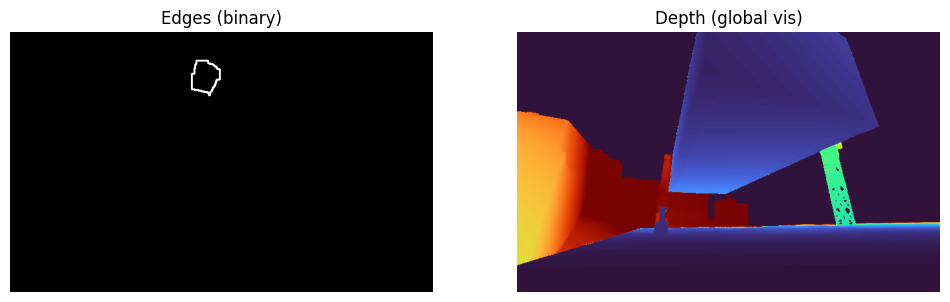

In [72]:
# Step 1: Load raw depth and edges, inspect (no unit scaling)
depth, edges_bin = load_raw(raw_dir)

if 'fx' in globals() and 'fy' in globals():
    depth_factored = depth_meter_to_pixel(depth, globals()['fx'], globals()['fy'])
else:
    depth_factored = depth

print('Depth shape:', depth.shape, 'dtype:', depth.dtype, 'min:', np.nanmin(depth), 'max:', np.nanmax(depth))
print('Edges shape:', edges_bin.shape, 'dtype:', edges_bin.dtype, 'nonzero:', int((edges_bin>0).sum()))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(edges_bin, cmap='gray'); axs[0].set_title('Edges (binary)'); axs[0].axis('off')
# Quick depth visualization (global)
valid = np.isfinite(depth) & (depth > 0)
if valid.any():
    dmin = float(np.percentile(depth[valid], 5)); dmax = float(np.percentile(depth[valid], 95))
    d_vis = visualize_depth(depth)
    axs[1].imshow(d_vis[..., ::-1]); axs[1].set_title('Depth (global vis)'); axs[1].axis('off')
else:
    axs[1].imshow(np.zeros((*depth.shape,3), dtype=np.uint8)); axs[1].set_title('Depth (no valid)'); axs[1].axis('off')
plt.show()

In [73]:
# Step 2: Optionally flatten far depths (depth > T := flatten_far_m)
#if flatten_far_m is not None:
#    T = float(flatten_far_m)
#    far_mask = np.isfinite(depth) & (depth > T)
#    changed = int(far_mask.sum())
#    if changed > 0:
#        depth = depth.copy(); depth[far_mask] = T
#    print(f'Flattened far depths above {T} m. Pixels changed:', changed)
#else:
#    print('No flattening applied.')

Buffered edges nonzero: 911


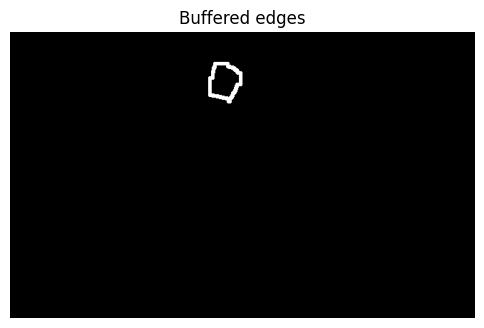

In [74]:
# Step 3: Buffer edges and visualize
buf = buffer_edges(edges_bin, buffer_px)
print('Buffered edges nonzero:', int((buf>0).sum()))

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(buf, cmap='gray'); ax.set_title('Buffered edges'); ax.axis('off')
plt.show()

ROI: (269, 35, 332, 108)
edges_roi shape: (74, 64) nonzero: 535


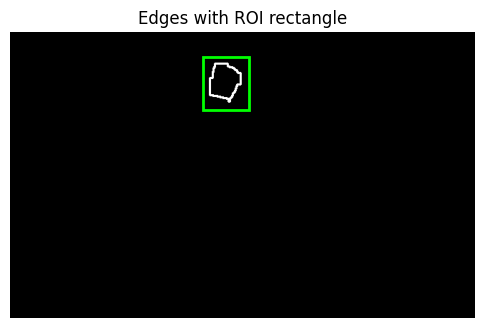

In [75]:
# Step 4: ROI from buffered mask
roi = compute_roi_from_mask(buf, roi_margin_px)
print('ROI:', roi)

# Produce an ROI version of the global edges for later corner filtering
edges_roi = None
if roi is not None:
    x1, y1, x2, y2 = roi
    edges_roi = edges_bin[y1:y2+1, x1:x2+1].copy()
    # Ensure binary 0/255
    edges_roi = (edges_roi > 0).astype(np.uint8) * 255
    print('edges_roi shape:', edges_roi.shape, 'nonzero:', int((edges_roi>0).sum()))
else:
    print('No ROI – edges_roi not created.')

# Visualize ROI rectangle on edges for context
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(edges_bin, cmap='gray')
if roi is not None:
    import matplotlib.patches as patches
    rect = patches.Rectangle((x1, y1), (x2-x1+1), (y2-y1+1), linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title('Edges with ROI rectangle')
else:
    ax.set_title('Edges (no ROI found)')
ax.axis('off')
plt.show()

depth_roi shape: (74, 64) min: 2.3361595 max: 4.532724


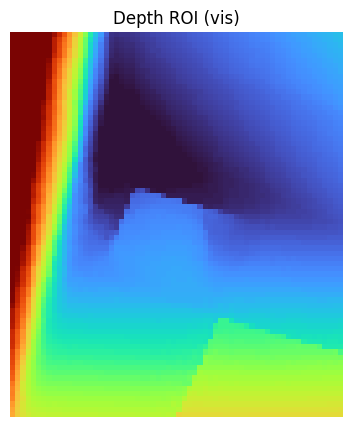

In [76]:
# Step 5: Clip depth to ROI and visualize
if roi is not None:
    x1, y1, x2, y2 = roi
    depth_roi = depth[y1:y2+1, x1:x2+1]
    print('depth_roi shape:', depth_roi.shape, 'min:', np.nanmin(depth_roi), 'max:', np.nanmax(depth_roi))
    depth_roi_vis = visualize_depth(depth_roi)
    plt.figure(figsize=(6,5))
    plt.imshow(depth_roi_vis[..., ::-1]); plt.title('Depth ROI (vis)'); plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping depth ROI step.')

Using original depth_roi for edge detection (no smoothed depth available).
Gradient shape: (74, 64) min: 0.0 max: 23.738182067871094
Depth-edges nonzero: 139


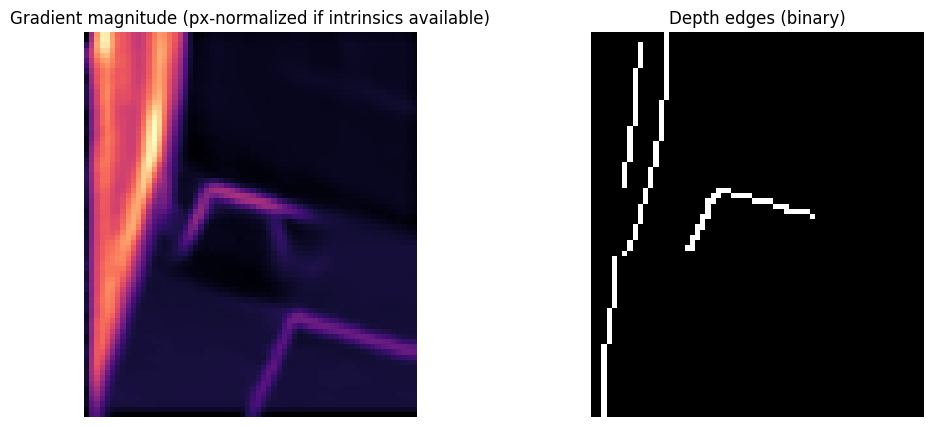

In [77]:
# Step 6: Detect depth edges inside ROI and visualize
if roi is not None:
    # Prefer smoothed depth if available from Step 5.5
    depth_for_edges =  depth_roi
    if 'depth_roi_smooth' in globals():
        print('Using smoothed depth (depth_roi_smooth) for edge detection.')
    else:
        print('Using original depth_roi for edge detection (no smoothed depth available).')
    
    grad, depth_edges = detect_depth_edges(depth_for_edges, method, edge_thresh, edge_sigma)
    print('Gradient shape:', grad.shape, 'min:', float(np.min(grad)), 'max:', float(np.max(grad)))
    print('Depth-edges nonzero:', int((depth_edges>0).sum()))
    
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    axs[0].imshow(grad, cmap='magma'); axs[0].set_title('Gradient magnitude (px-normalized if intrinsics available)'); axs[0].axis('off')
    axs[1].imshow(depth_edges, cmap='gray'); axs[1].set_title('Depth edges (binary)'); axs[1].axis('off')
    plt.show()
else:
    print('No ROI – skipping edge detection step.')

# Step 7: Identify corners on the detected edges
We detect salient corner points along the edge map inside the ROI using Shi–Tomasi (`cv2.goodFeaturesToTrack`) restricted by the edge mask, and visualize them on the depth ROI.

Detected corners: 5


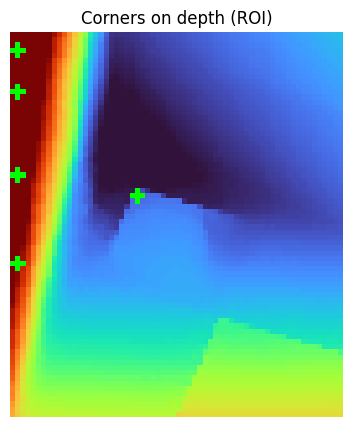

In [78]:
# Step 7: Corner detection on depth within ROI
if roi is not None:
    # Convert depth ROI (float32) to single-channel 8-bit for corner detection
    d = fill_invalid_with_median(depth_roi.astype(np.float32))
    d_blur = cv2.GaussianBlur(d, (3, 3), 0)
    d_norm = cv2.normalize(d_blur, None, 0, 255, cv2.NORM_MINMAX)
    depth_gray = d_norm.astype(np.uint8)

    # Parameters for Shi–Tomasi corner detection
    max_corners = 5   # maximum number of corners to return
    quality_level = 0.01  # minimal accepted quality (0..1)
    min_distance = 3     # minimum possible Euclidean distance between returned corners (in px)

    corners = cv2.goodFeaturesToTrack(
        image=depth_gray,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance,
        mask=None,  # optionally restrict with an edge or ROI mask
        blockSize=3,
        useHarrisDetector=False,
        k=0.04
    )

    corners_px = np.empty((0,2), dtype=np.float32) if corners is None else corners.squeeze(1).astype(np.float32)
    print('Detected corners:', int(len(corners_px)))

    # Visualize corners over depth ROI visualization
    vis = (depth_roi_vis.copy() if 'depth_roi_vis' in globals() else cv2.cvtColor(depth_gray, cv2.COLOR_GRAY2BGR))
    for (x, y) in corners_px:
        cv2.circle(vis, (int(round(x)), int(round(y))), 1, (0, 255, 0), -1)

    plt.figure(figsize=(6,5))
    plt.imshow(vis[..., ::-1])
    plt.title('Corners on depth (ROI)')
    plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping corner detection.')

Total corners: 5, inside filled region: 1
[[293.      66.       2.4987]]


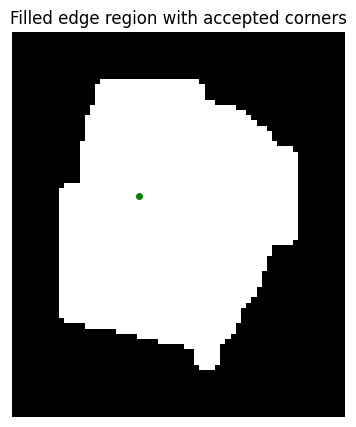

In [79]:
# Step 8: Filter corners within filled edge region and print (x, y, depth)
# Adjusted: use edges_roi (cropped) directly; fill interior by flood-fill if edges form a closed contour.
# If edges_roi absent, fall back to offsetting ROI corners onto global edges.

missing = []
for name in ['corners_px', 'depth', 'depth_roi', 'roi']:
    if name not in globals():
        missing.append(name)
if missing:
    print('Missing variables for Step 8:', missing)
else:
    if roi is None:
        print('No ROI defined; cannot proceed.')
    else:
        x1, y1, x2, y2 = roi
        # Prepare edge mask inside ROI
        if 'edges_roi' in globals() and edges_roi is not None:
            mask_edge = (edges_roi > 0).astype(np.uint8)
            # Fill interior: flood fill from borders as background then invert
            h, w = mask_edge.shape
            ff = mask_edge.copy()
            # Build background mask: start with zeros, flood from boundary pixels that are zero
            bg = np.zeros_like(ff)
            from collections import deque
            dq = deque()
            # enqueue all border zeros
            for i in range(w):
                if ff[0, i] == 0: dq.append((0, i))
                if ff[h-1, i] == 0: dq.append((h-1, i))
            for j in range(h):
                if ff[j, 0] == 0: dq.append((j, 0))
                if ff[j, w-1] == 0: dq.append((j, w-1))
            while dq:
                yy, xx = dq.popleft()
                if bg[yy, xx]:
                    continue
                bg[yy, xx] = 1
                for dy, dx in ((1,0),(-1,0),(0,1),(0,-1)):
                    ny, nx = yy+dy, xx+dx
                    if 0 <= ny < h and 0 <= nx < w and ff[ny, nx] == 0 and bg[ny, nx] == 0:
                        dq.append((ny, nx))
            # Interior = not background and not edge
            interior = (bg == 0) & (ff == 0)
            filled = ((ff > 0) | interior).astype(np.uint8)
            edges_filled = filled * 255
        else:
            print('edges_roi missing; will build mask by offsetting ROI onto global edges.')
            edges_local = edges_bin[y1:y2+1, x1:x2+1]
            edges_filled = (edges_local > 0).astype(np.uint8) * 255

        if corners_px is None or len(corners_px) == 0:
            print('No corners to filter.')
        else:
            xy_roi = corners_px.astype(np.float32)
            xi_roi = np.clip(np.rint(xy_roi[:, 0]).astype(int), 0, edges_filled.shape[1]-1)
            yi_roi = np.clip(np.rint(xy_roi[:, 1]).astype(int), 0, edges_filled.shape[0]-1)
            inside = (edges_filled[yi_roi, xi_roi] > 0)
            corners_px_inside = xy_roi[inside]

            # Convert to absolute coordinates
            corners_abs = corners_px_inside + np.array([x1, y1], dtype=np.float32)
            xa = np.clip(np.rint(corners_abs[:, 0]).astype(int), 0, depth.shape[1]-1)
            ya = np.clip(np.rint(corners_abs[:, 1]).astype(int), 0, depth.shape[0]-1)
            depths = depth[ya, xa].astype(np.float32)

            print(f'Total corners: {len(corners_px)}, inside filled region: {len(corners_px_inside)}')
            out = np.column_stack([xa, ya, depths])
            np.set_printoptions(precision=4, suppress=True)
            print(out)

            # Visualization of filled mask and accepted corners
            fig, ax = plt.subplots(1, 1, figsize=(6,5))
            ax.imshow(edges_filled, cmap='gray')
            for (x, y) in corners_px_inside:
                ax.plot(x, y, 'go', markersize=4)
            ax.set_title('Filled edge region with accepted corners')
            ax.axis('off')
            plt.show()

In [80]:
# Step 9: Compare socket metadata depth with detected corner depths
import os, json
import numpy as np

# Find a nearby frame_data json (Unity SOLO)
_names = ['step0.frame_data.json', 'frame_data.json']
_starts = []
if 'raw_dir' in globals() and raw_dir:
    _starts += [raw_dir, os.path.dirname(raw_dir), os.path.dirname(os.path.dirname(raw_dir))]
if 'search_roots' in globals():
    _starts += list(search_roots)
# Add common relative locations from this notebook directory and repo root
_nb_dir = os.getcwd()
_starts += [
    os.path.join(_nb_dir, 'scripts', 'run_files', 'micro', 'input_3d_blocks'),
    os.path.join(_nb_dir, 'scripts', 'run_files', 'macro', 'input_3d_blocks'),
    os.path.join(_nb_dir, 'image_sample'),
    os.path.abspath(os.path.join(_nb_dir, '..', '..', 'scripts', 'run_files', 'micro', 'input_3d_blocks')),
    os.path.abspath(os.path.join(_nb_dir, '..', '..', 'scripts', 'run_files', 'macro', 'input_3d_blocks')),
    os.path.abspath(os.path.join(_nb_dir, '..', '..', 'image_sample')),
]

def _find_json(_roots, _names):
    _names = [n.lower() for n in _names]
    for r in _roots:
        try:
            ra = os.path.abspath(r)
            if not os.path.isdir(ra):
                continue
            for dp, dns, fns in os.walk(ra):
                for fn in fns:
                    if fn.lower() in _names:
                        return os.path.join(dp, fn)
        except Exception:
            pass
    return None

_step0_json = _find_json(_starts, _names)
if _step0_json is None:
    print('Step 9: No frame_data json found near run. Skipping comparison.')
else:
    print('Step 9: Using frame data ->', _step0_json)
    with open(_step0_json, 'r') as f:
        _fd = json.load(f)

    # Pick capture that has both Depth and 3D boxes (if possible)
    _cap = None
    for c in _fd.get('captures', []):
        anns = c.get('annotations', [])
        has_depth = any(a.get('@type', '').endswith('DepthAnnotation') for a in anns)
        has_bbox = any(a.get('@type', '').endswith('BoundingBox3DAnnotation') for a in anns)
        if has_depth and has_bbox:
            _cap = c
            break
    if _cap is None:
        _caps = _fd.get('captures', [])
        _cap = _caps[0] if _caps else None

    # Extract Socket translation in camera coordinates from BoundingBox3DAnnotation
    socket_trans = None  # [X,Y,Z] in camera coords
    if _cap is not None:
        for a in _cap.get('annotations', []):
            if a.get('@type', '').endswith('BoundingBox3DAnnotation'):
                for v in a.get('values', []):
                    name = str(v.get('labelName', v.get('label_name', ''))).lower()
                    if name.startswith('socket'):
                        t = v.get('translation')
                        if isinstance(t, (list, tuple)) and len(t) == 3:
                            socket_trans = [float(t[0]), float(t[1]), float(t[2])]
                        break
                if socket_trans is not None:
                    break

    # Fallback: metrics metadata (often world coords; needs extrinsics to convert)
    if socket_trans is None:
        for m in _fd.get('metrics', []):
            if m.get('id') == 'metadata':
                vals = m.get('values', [])
                if vals:
                    insts = vals[0].get('instances', [])
                    for inst in insts:
                        tr = inst.get('transformRecord', {})
                        pname = str(tr.get('parentName', '')).lower()
                        if 'socket' in pname:
                            pos_world = tr.get('position', None)
                            if isinstance(pos_world, (list, tuple)) and len(pos_world) == 3:
                                print('Socket world position (no camera translation available):', pos_world)
                break

    if socket_trans is None:
        print('Socket translation in camera coordinates not found in JSON.')
    else:
        z_cam = float(socket_trans[2])
        dist_cam = float(np.linalg.norm(np.array(socket_trans, dtype=np.float32)))
        print(f'Socket translation (camera coords) XYZ: {np.round(socket_trans, 4).tolist()}')
        print(f'  Forward depth Z: {z_cam:.4f} m, Euclidean distance: {dist_cam:.4f} m')

        # Compare with detected corner depths from Step 8 (`out` = [x_abs, y_abs, depth_m])
        if 'out' not in globals():
            print('No detected corner depths (variable `out` missing). Run Step 8 first.')
        elif out is None or len(out) == 0:
            print('No detected corners to compare.')
        else:
            _out = np.asarray(out)
            depths = _out[:, 2].astype(np.float32)
            diffs_z = depths - z_cam
            diffs_e = depths - dist_cam
            print('Detected corner depths (m):', np.round(depths, 4))
            print('Depth - socket Z (m):      ', np.round(diffs_z, 4))
            print('Depth - socket ||t|| (m):  ', np.round(diffs_e, 4))
            print(f'Misalignment vs Z -> mean={diffs_z.mean():.4f}, absmean={np.abs(diffs_z).mean():.4f}, maxabs={np.max(np.abs(diffs_z)):.4f}')

            # If intrinsics known, project socket to pixel and compare pixel offsets
            if all(k in globals() for k in ['fx', 'fy', 'cx', 'cy']):
                fxv, fyv, cxv, cyv = float(fx), float(fy), float(cx), float(cy)
                X, Y, Z = socket_trans
                if abs(Z) > 1e-6:
                    u = cxv + fxv * (X / Z)
                    v = cyv + fyv * (Y / Z)
                    px = _out[:, 0].astype(np.float32)
                    py = _out[:, 1].astype(np.float32)
                    dpx = np.sqrt((px - u) ** 2 + (py - v) ** 2)
                    print(f'Projected socket pixel (u,v): ({u:.2f}, {v:.2f})')
                    print('Pixel distance to socket proj (px):', np.round(dpx, 2))
            else:
                print('Intrinsics (fx, fy, cx, cy) not available; skipping pixel misalignment check.')


Step 9: Using frame data -> c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\micro\input_3d_blocks\step0.frame_data.json
Socket translation (camera coords) XYZ: [-0.2551, 1.3829, 2.5802]
  Forward depth Z: 2.5802 m, Euclidean distance: 2.9385 m
Detected corner depths (m): [2.4987]
Depth - socket Z (m):       [-0.0815]
Depth - socket ||t|| (m):   [-0.4398]
Misalignment vs Z -> mean=-0.0815, absmean=0.0815, maxabs=0.0815
Projected socket pixel (u,v): (299.89, 336.08)
Pixel distance to socket proj (px): [270.17]
